# El Aprendizaje como Optimización
**Objetivo del bloque**: entender el núcleo matemático del entrenamiento.
Medir cuanto se equivoca la red, calcular en que dirección ajustar los pesos,
y aplicar esa corrección de forma eficiente.

El entrenamiento de una red neuronal es inferencia científica:
buscar la hipótesis (configuración de pesos) que mejor explica los datos observados.

---

**Estructura del notebook:**
1. Función de pérdida - como medir el error de forma diferenciable
2. Backpropagation - la regla de la cadena aplicada capa a capa
3. Optimizadores - de SGD a Adam, por que existen variantes
4. Regularización - overfitting, dropout, L1/L2
5. Pipeline completo de entrenamiento
6. Experimento: efecto del learning rate en la convergencia

In [1]:
# Crear directorio de exportacion de imagenes
import os
os.makedirs('images', exist_ok=True)
print('[OK] Directorio images/ listo')

[OK] Directorio images/ listo


In [2]:
# Setup
from pathlib import Path
import os

SCRIPTS = Path('..') / 'ejemplos_codigo'
if not SCRIPTS.is_dir():
    raise FileNotFoundError(
        f"No se encuentra '{SCRIPTS.resolve()}'.\n"
        "Ejecuta este notebook desde la carpeta Jupyter_notebooks/"
    )

os.chdir(SCRIPTS)
print(f"[OK] Directorio de scripts: {os.getcwd()}")

%pip install -q scikit-learn matplotlib numpy
%matplotlib inline

[OK] Directorio de scripts: D:\documentos_gdrive\proyectos_claude_mcp\projects\formación_AI_springter\ejemplos_codigo
Note: you may need to restart the kernel to use updated packages.


---
## 1. Función de Pérdida: medir el error de forma diferenciable

La función de pérdida cuantifica como de malas son las predicciones.
Es la métrica que el optimizador intentará minimizar.

### Categorical Cross-Entropy
La estándar para clasificación multiclase con salida Softmax:

```
L = -log(prob_predicha_de_la_clase_correcta)
```

Interpretación directa:
- Si el modelo asigna probabilidad 1.0 a la clase correcta: L = -log(1.0) = 0 (perfecto)
- Si asigna probabilidad 0.1: L = -log(0.1) = 2.3 (bastante mal)
- Si asigna probabilidad 0.01: L = -log(0.01) = 4.6 (muy mal)

### Accuracy vs Loss: por que el loss es mejor guia de entrenamiento
La accuracy solo cuenta aciertos. No distingue entre:
- Un modelo que predice [0.51, 0.49] (seguro: acierta, pero por los pelos)
- Un modelo que predice [0.99, 0.01] (mucho mejor: acierta con confianza)

El loss captura la diferencia de confianza. Por eso guia el entrenamiento.

> **Antes de seguir:** ¿en qué proceso de tu trabajo cometes los dos tipos de error (actuar cuando no debías, o no actuar cuando debías), y cuál de los dos tiene consecuencias más graves para el negocio?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

**Una respuesta madura menciona al menos uno de estos elementos:**
- Un caso concreto donde el coste de equivocarse en una dirección es claramente mayor que en la otra (escalar un ticket que no era urgente vs. ignorar uno que sí lo era)
- La intuición de que el umbral de decisión óptimo no es siempre el punto medio
- Que esa asimetría es una decisión de negocio que el equipo debe tomar antes de entrenar el modelo

**Si nadie responde, preguntar:**
"Si vuestro modelo de detección de fraude se equivoca, ¿preferís bloquear una transacción legítima o aprobar una fraudulenta? ¿Por qué? ¿Cambia la respuesta según el importe?"

**Señal de comprensión:**
El alumno puede nombrar los dos tipos de error en su dominio y decir cuál es más costoso. Si además identifica que ese juicio debería fijar el umbral del modelo, ha entendido la conexión entre negocio y técnica que vertebra este bloque.

</details>

In [3]:
# Categorical Cross-Entropy: calculo e interpretacion
# Incluye demostracion del efecto de -log sobre la confianza
%run 04_loss_crossentropy.py

=== Categorical Cross-Entropy Loss ===
Predicciones:
[[0.7  0.1  0.2 ]
 [0.1  0.5  0.4 ]
 [0.02 0.9  0.08]]
Etiquetas reales: [0 1 1]
Loss: 0.38506
Accuracy: 100.00%

=== Efecto de -log en la confianza ===
  Confianza 0.99 -> Loss: 0.0101
  Confianza 0.90 -> Loss: 0.1054
  Confianza 0.70 -> Loss: 0.3567
  Confianza 0.50 -> Loss: 0.6931
  Confianza 0.30 -> Loss: 1.2040
  Confianza 0.10 -> Loss: 2.3026
  Confianza 0.01 -> Loss: 4.6052

=== Con etiquetas one-hot ===
Loss (one-hot, target clase 2 en muestra 3): 1.19185


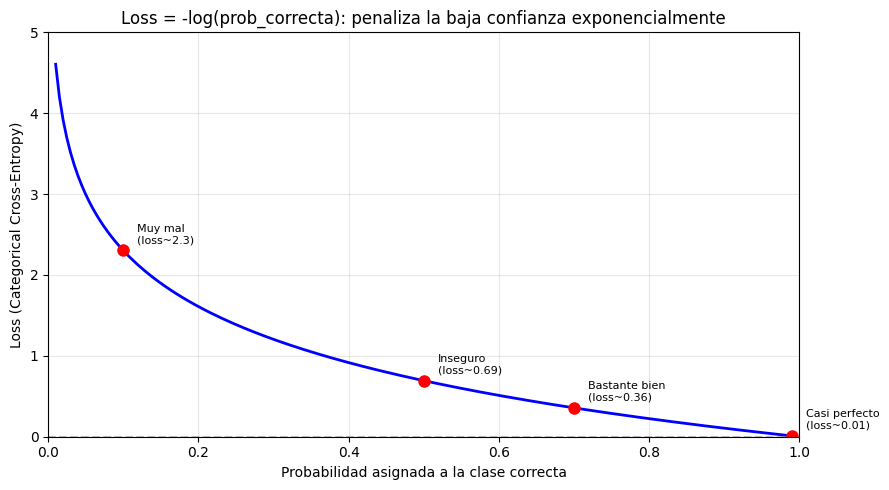

La curva explica por que el loss es mejor guia que la accuracy:
penaliza agresivamente las predicciones inseguras aunque sean tecnicamente correctas.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizar la funcion -log(p) y su efecto pedagogico
p = np.linspace(0.01, 0.99, 200)
loss = -np.log(p)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p, loss, 'b-', linewidth=2)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Anotar puntos clave
puntos = [(0.99, 'Casi perfecto\n(loss~0.01)'),
          (0.70, 'Bastante bien\n(loss~0.36)'),
          (0.50, 'Inseguro\n(loss~0.69)'),
          (0.10, 'Muy mal\n(loss~2.3)')]

for px, label in puntos:
    py = -np.log(px)
    ax.plot(px, py, 'ro', markersize=8)
    ax.annotate(label, (px, py), textcoords='offset points',
                xytext=(10, 5), fontsize=8)

ax.set_xlabel('Probabilidad asignada a la clase correcta')
ax.set_ylabel('Loss (Categorical Cross-Entropy)')
ax.set_title('Loss = -log(prob_correcta): penaliza la baja confianza exponencialmente')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
plt.tight_layout()
plt.savefig('images/B04_fig01.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("La curva explica por que el loss es mejor guia que la accuracy:")
print("penaliza agresivamente las predicciones inseguras aunque sean tecnicamente correctas.")

---
## 2. Backpropagation: la regla de la cadena

Backpropagation permite entrenar redes profundas.
Usa la regla de la cadena para propagar el gradiente del loss hacia atrás,
desde la capa de salida hasta la primera capa oculta.

**Que calcula:**
Para cada parámetro (peso, sesgo), el gradiente indica:
- En que dirección moverlo para reducir el loss
- Cuanto moverlo (magnitud del gradiente)

**La simplificación elegante de Softmax + Cross-Entropy:**
```
dL/dz = y_predicha - y_real
```
El gradiente combinado es simplemente la diferencia entre la predicción y la realidad.
Intuitivo y computacionalmente eficiente.

**Por que esto funciona:**
El training es búsqueda de la mejor hipótesis (pesos).
Si el modelo no puede separar señal de ruido en los datos,
no encontrará la hipótesis correcta independientemente del algoritmo.

In [5]:
# Backpropagation: calculo de gradientes capa a capa
# Muestra los gradientes de pesos y sesgos despues del backward pass
%run 05_backpropagation.py

=== la empresa Pass ===
Loss: 1.09859
Accuracy: 36.00%

=== Backward Pass (gradientes calculados) ===
Gradientes de dense1.weights: shape (2, 64), media -0.000005
Gradientes de dense1.biases:  shape (1, 64), media -0.000054
Gradientes de dense2.weights: shape (64, 3), media 0.000000
Gradientes de dense2.biases:  shape (1, 3), media -0.000000


<Figure size 640x480 with 0 Axes>

---
## 3. Optimizadores: de SGD a Adam

La actualización más básica:
```
parametro = parametro - learning_rate * gradiente
```

Esta fórmula simple tiene problemas que los optimizadores modernos resuelven:

| Optimizador | Idea clave | Cuando usarlo |
|---|---|---|
| SGD | Paso fijo en la dirección del gradiente | Baseline, cuando se tiene mucho control |
| SGD + Momentum | Acumula inercia, suaviza oscilaciones | Cuando SGD oscila mucho |
| AdaGrad | Learning rate distinto por parámetro | Cuando hay features con escalas muy distintas |
| RMSProp | Media movil del gradiente^2 (olvida los antiguos) | Cuando AdaGrad decae demasiado |
| Adam | Momentum + RMSProp + corrección de sesgo | Por defecto en casi todo |

**Adam en la práctica:**
Los valores por defecto (lr=0.001, beta1=0.9, beta2=0.999) funcionan bien en la mayoría de casos.
El parámetro que más se suele ajustar es solo el learning rate.

In [6]:
# Optimizadores: SGD, AdaGrad, RMSProp, Adam
# Entrenamiento con Adam y comparativa de convergencia
%run 06_optimizadores.py

=== Entrenamiento con Adam ===
Epoch     0 | Loss: 1.09859 | Acc: 0.3600 | LR: 0.020000
Epoch  1000 | Loss: 0.24326 | Acc: 0.9067 | LR: 0.019990
Epoch  2000 | Loss: 0.15828 | Acc: 0.9367 | LR: 0.019980
Epoch  3000 | Loss: 0.13213 | Acc: 0.9500 | LR: 0.019970
Epoch  4000 | Loss: 0.11747 | Acc: 0.9567 | LR: 0.019960
Epoch  5000 | Loss: 0.11016 | Acc: 0.9533 | LR: 0.019950
Epoch  6000 | Loss: 0.10054 | Acc: 0.9700 | LR: 0.019940
Epoch  7000 | Loss: 0.09609 | Acc: 0.9700 | LR: 0.019930
Epoch  8000 | Loss: 0.09227 | Acc: 0.9700 | LR: 0.019920
Epoch  9000 | Loss: 0.08996 | Acc: 0.9700 | LR: 0.019910
Epoch 10000 | Loss: 0.08880 | Acc: 0.9667 | LR: 0.019901


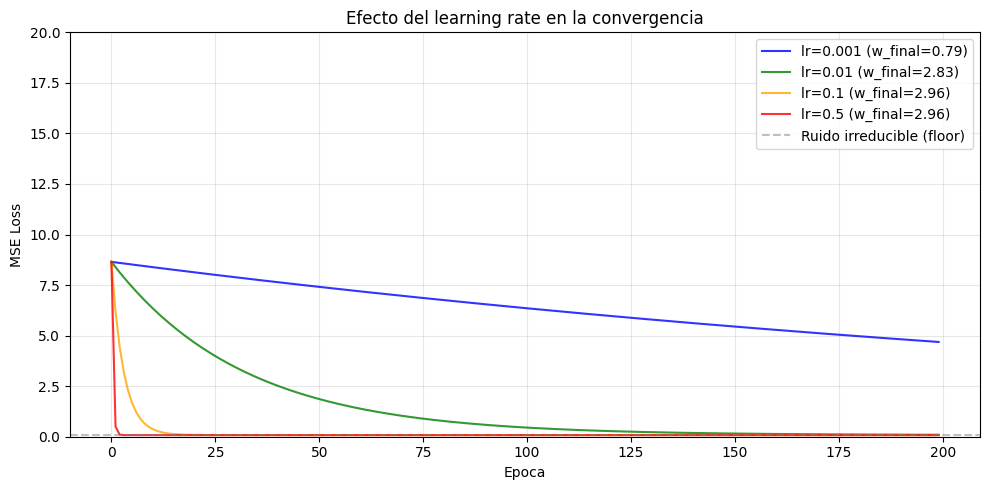

Observaciones:
  lr=0.001 : converge muy lento (muchas epocas necesarias)
  lr=0.01  : convergencia estable, buen punto de partida
  lr=0.1   : converge rapido pero puede oscilar al final
  lr=0.5   : demasiado grande, diverge o oscila sin converger

El learning rate es el hiperparametro mas importante a ajustar.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Experimento: efecto del learning rate en la convergencia
# Funcion de ejemplo: MSE de un problema de regresion simple

np.random.seed(42)
n = 100
X = np.random.randn(n)
y_true = 3.0 * X + 1.5 + 0.3 * np.random.randn(n)  # y = 3x + 1.5 + ruido

def entrenar_sgd(lr, n_epochs=200):
    """Descenso del gradiente para regresion lineal simple: y = w*x + b"""
    w, b = 0.0, 0.0
    losses = []
    for _ in range(n_epochs):
        y_pred = w * X + b
        loss = np.mean((y_pred - y_true) ** 2)
        losses.append(loss)
        # Gradientes
        dw = 2 * np.mean((y_pred - y_true) * X)
        db = 2 * np.mean(y_pred - y_true)
        w -= lr * dw
        b -= lr * db
    return losses, w, b

learning_rates = [0.001, 0.01, 0.1, 0.5]
colores = ['blue', 'green', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 5))

for lr, color in zip(learning_rates, colores):
    losses, w_final, b_final = entrenar_sgd(lr)
    ax.plot(losses, color=color, label=f'lr={lr} (w_final={w_final:.2f})', alpha=0.8)

ax.axhline(y=0.09, color='gray', linestyle='--', alpha=0.5, label='Ruido irreducible (floor)')
ax.set_xlabel('Epoca')
ax.set_ylabel('MSE Loss')
ax.set_title('Efecto del learning rate en la convergencia')
ax.legend()
ax.set_ylim(0, 20)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/B04_fig02.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("Observaciones:")
print("  lr=0.001 : converge muy lento (muchas epocas necesarias)")
print("  lr=0.01  : convergencia estable, buen punto de partida")
print("  lr=0.1   : converge rapido pero puede oscilar al final")
print("  lr=0.5   : demasiado grande, diverge o oscila sin converger")
print()
print("El learning rate es el hiperparametro mas importante a ajustar.")

---
## 4. Regularización: prevenir el overfitting

El overfitting ocurre cuando el modelo **memoriza** los datos de entrenamiento
en lugar de aprender los patrones subyacentes.

Síntoma: accuracy alta en entrenamiento, baja en datos nuevos.

**Tres técnicas principales:**

1. **L2 (Ridge)**: penaliza la magnitud de los pesos. Evita que un solo peso
   domine el modelo. Añade `lambda * sum(w^2)` al loss.

2. **Dropout**: desactiva aleatoriamente un porcentaje de neuronas en cada paso.
   Fuerza a la red a distribuir la representación y no depender de neuronas individuales.

3. **Validación out-of-sample**: la única forma de saber si el modelo generaliza
   es probarlo con datos que nunca ha visto.
   Práctica estándar: 70% entrenamiento / 15% validación / 15% test.

In [8]:
# Red completa con L2, dropout y validacion out-of-sample
# Muestra la diferencia entre loss de entrenamiento y test
%run 07_red_completa_entrenamiento.py

=== Entrenamiento: Red completa con Dropout y Regularizacion L2 ===

Epoch     0 | Loss: 1.09861 (data: 1.09861, reg: 0.00001) | Acc: 0.3367 | LR: 0.050000
Epoch  1000 | Loss: 0.76457 (data: 0.71607, reg: 0.04850) | Acc: 0.6733 | LR: 0.047621
Epoch  2000 | Loss: 0.71678 (data: 0.66554, reg: 0.05124) | Acc: 0.7000 | LR: 0.045457
Epoch  3000 | Loss: 0.75033 (data: 0.69912, reg: 0.05121) | Acc: 0.7333 | LR: 0.043480
Epoch  4000 | Loss: 0.75890 (data: 0.71068, reg: 0.04823) | Acc: 0.7067 | LR: 0.041668
Epoch  5000 | Loss: 0.70144 (data: 0.65343, reg: 0.04802) | Acc: 0.7333 | LR: 0.040002
Epoch  6000 | Loss: 0.58470 (data: 0.53828, reg: 0.04642) | Acc: 0.7733 | LR: 0.038463
Epoch  7000 | Loss: 0.67089 (data: 0.62446, reg: 0.04643) | Acc: 0.7567 | LR: 0.037038
Epoch  8000 | Loss: 0.67336 (data: 0.62676, reg: 0.04659) | Acc: 0.7733 | LR: 0.035716
Epoch  9000 | Loss: 0.70542 (data: 0.65900, reg: 0.04641) | Acc: 0.7400 | LR: 0.034484
Epoch 10000 | Loss: 0.67588 (data: 0.62960, reg: 0.04629) | A

<Figure size 640x480 with 0 Axes>

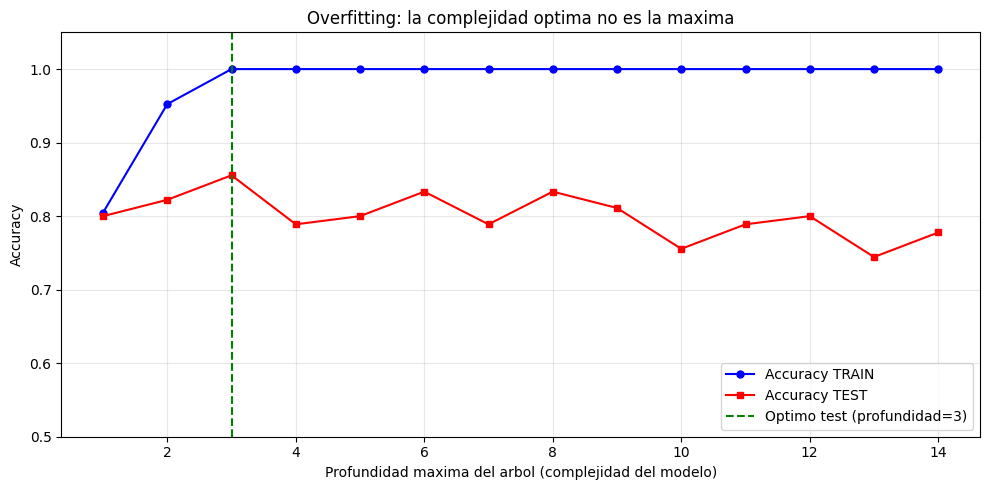

Observacion:
  El modelo mas complejo (profundidad alta) tiene accuracy=1.0 en entrenamiento.
  Pero peor en test: memorizo los datos en lugar de aprender el patron.
  La complejidad optima es la que maximiza el test, no el entrenamiento.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Demostracion de overfitting: modelo demasiado complejo vs modelo adecuado
X, y = make_classification(n_samples=300, n_features=10, n_informative=4,
                            random_state=42, class_sep=0.8)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Variar la profundidad del arbol (proxy para la complejidad del modelo)
profundidades = list(range(1, 15))
acc_train, acc_test = [], []

for d in profundidades:
    modelo = GradientBoostingClassifier(max_depth=d, n_estimators=50, random_state=42)
    modelo.fit(X_train, y_train)
    acc_train.append(accuracy_score(y_train, modelo.predict(X_train)))
    acc_test.append(accuracy_score(y_test, modelo.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(profundidades, acc_train, 'b-o', label='Accuracy TRAIN', markersize=5)
ax.plot(profundidades, acc_test, 'r-s', label='Accuracy TEST', markersize=5)
ax.axvline(x=profundidades[np.argmax(acc_test)],
           color='green', linestyle='--',
           label=f'Optimo test (profundidad={profundidades[np.argmax(acc_test)]})')
ax.set_xlabel('Profundidad maxima del arbol (complejidad del modelo)')
ax.set_ylabel('Accuracy')
ax.set_title('Overfitting: la complejidad optima no es la maxima')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.savefig('images/B04_fig03.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("Observacion:")
print("  El modelo mas complejo (profundidad alta) tiene accuracy=1.0 en entrenamiento.")
print("  Pero peor en test: memorizo los datos en lugar de aprender el patron.")
print("  La complejidad optima es la que maximiza el test, no el entrenamiento.")

---
## 7. Ejercicio de Decisión: ¿usarías IA aquí?

### Caso: el modelo que funciona bien en test pero mal en producción

El modelo de predicción de renovación de contratos de un cliente de la empresa tiene
94% de accuracy en el conjunto de test. Lleva 2 meses en producción.
El equipo comercial dice que "las predicciones no se parecen a la realidad":
están recibiendo alertas de riesgo sobre clientes que luego renuevan sin problema,
y clientes que no aparecen como riesgo que después cancelan.

Dato adicional: el 91% de los contratos históricos se han renovado.

---

**Pregunta 1 - La métrica**
¿Que significa "94% de accuracy" dado que el 91% se renueva?
¿Es ese un modelo útil? Justifica numéricamente.

**Pregunta 2 - Las causas posibles**
Lista al menos 3 razones por las que un modelo puede funcionar bien en test
y mal en producción.

**Pregunta 3 - Las métricas alternativas**
¿Que métricas usarías en lugar de accuracy para este problema?
¿Por que son más adecuadas?

**Pregunta 4 - El siguiente paso**
¿Que harías ahora: reentrenar, recoger más datos, revisar las métricas, o retirar el modelo?
¿En que orden y por que?

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - La métrica:**

*(escribe aquí)*

**Pregunta 2 - Las causas posibles:**

*(escribe aquí)*

**Pregunta 3 - Las métricas alternativas:**

*(escribe aquí)*

**Pregunta 4 - El siguiente paso:**

*(escribe aquí)*

---

<!--
CRITERIOS DE Evaluación (para el instructor)

Pregunta 1 - La métrica:
Respuesta correcta: un modelo que siempre predice "renueva" tiene 91% de accuracy.
El modelo con 94% solo supera la línea base en 3 puntos porcentuales y probablemente
no detecta ningún caso de no-renovación.
Esto se llama clase mayoritaria o majority class baseline.
Insuficiente: "es un modelo bueno porque tiene 94%".
Incorrecto: no relacionar el 94% con el 91% de base.

Pregunta 2 - Las causas posibles:
Al menos 3 de estas son válidas:
 - Data leakage: variables en train que no existen en producción
 - Dataset shift: el perfil de clientes cambió desde que se entrenaron los datos
 - Overfitting: el modelo memorizó el train y no generaliza
 - Etiquetas incorrectas: la variable objetivo en train no coincide con lo que pasa realmente
 - Desequilibrio no tratado: el modelo aprende solo la clase mayoritaria
Incompleto: solo mencionar overfitting sin otras causas.

Pregunta 3 - Las métricas alternativas:
Correctas para este problema: precisión, recall, F1 sobre la clase minoritaria (no-renovación),
AUC-ROC, o matriz de confusión.
Justificación necesaria: en problemas con clases desbalanceadas, accuracy es una métrica
engañosa que oculta el rendimiento real sobre la clase crítica.
Insuficiente: proponer una métrica sin explicar por que es mejor que accuracy.

Pregunta 4 - El siguiente paso:
Orden correcto: primero revisar métricas (entender donde falla),
luego diagnosticar causa (leakage, drift, overfitting),
luego decidir si reentrenar o retirar.
Incorrecto: reentrenar directamente sin diagnóstico.
Penalizar: "pedir más datos" como primera acción sin haber diagnosticado el problema.
-->


---
## Puntos clave del Bloque 4

1. **El loss es la brújula del entrenamiento**: mide el error de forma diferenciable
   y captura la confianza del modelo, no solo los aciertos.

2. **Backpropagation = regla de la cadena**: el gradiente de cada peso indica
   en que dirección y cuanto moverlo para reducir el error.

3. **Adam es el punto de partida**: combina momentum y learning rate adaptativo.
   En la práctica, solo ajustar el learning rate resuelve el 80% de los problemas.

4. **El overfitting se detecta con datos de test**: si train accuracy >> test accuracy,
   el modelo memorizó los datos. Dropout, L2, y más datos son las soluciones.

5. **Entrena es buscar la mejor hipótesis**: si los datos no contienen la señal necesaria,
   ningún optimizador la encontrará. Los datos son el límite, no el algoritmo.

---
**Siguiente bloque**: Arquitecturas Profundas - 
el mapa de arquitecturas especializadas: CNN, RNN, LSTM, GAN, Transformer.